# Stage 3 hands-on — solar radiation with shading (GRASS `r.sun`)

This notebook explores pipeline **stage 3**: turn the DSM from `01_footprints_and_dsm` into
**per-cell insolation (Wh/m2/day, then kWh/m2/yr) that accounts for inter-building shading**.

**Why GRASS `r.sun`, not pure Python:** no pure-Python raster solar model does terrain/horizon
shadowing at this fidelity — GRASS GIS is a system dependency (installed separately, called via
subprocess/`grass.script`), not a pip package. This is a locked decision (risks §14.2).

Two of the four shading traps (risks §8) live squarely in this stage:

- **Trap 3 — shadow search distance.** `r.sun`'s horizon search has a finite radius. Set it too
  short and a far, tall tower stops casting a shadow it really does cast (an issue downtown; our
  tiny AOI is low-rise, so it barely bites here, but production must set it deliberately).
- **Trap 4 — don't let PVWatts undo the shading.** PVWatts assumes an *unshaded* horizon. Stage 6
  must feed it the shading-adjusted insolation (or a shading-loss factor) from *this* stage, never
  the raw NSRDB/TMY value — or stages 2–3 are wasted work.

Same tiny, self-contained AOI as `01` (a ~400 m slice of Glover Park, buffered 100 m in a metric
CRS) so this runs fast and every step is inspectable.

## The plan

1. Fetch the tiny DSM (condensed from `01`) + OSM footprints for the map overlay.
2. Spin up a throwaway GRASS **location/mapset** bound to our metric CRS, import the DSM, derive
   slope + aspect (`r.slope.aspect`).
3. Run `r.sun` for one representative day, **with** shadowing (default) and **without**
   (`flags="p"`), and look at the difference.
4. Prove the shading is real: map it, and quantify the loss inside footprints vs. open ground.
5. Sample 12 mid-month days and weight by days-in-month to approximate an **annual, shaded**
   insolation surface — the thing stage 6 (PVWatts) actually needs (trap 4).

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import osmnx as ox
import planetary_computer as pc
import pyproj
import pystac_client
import rasterio
from rasterio.crs import CRS
from rasterio.merge import merge
from rasterio.transform import from_origin
from rasterio.warp import Resampling, reproject
from shapely.geometry import Polygon, box, mapping
from shapely.ops import transform as shp_transform

warnings.filterwarnings("ignore")  # keep the notebook output clean for reading

PC_STAC = "https://planetarycomputer.microsoft.com/api/stac/v1"
WORKING_CRS = "EPSG:6347"  # NAD83(2011) / UTM 18N -- metric, covers DC

# Same tiny AOI as 01, buffered 100 m in the metric CRS (never in degrees -- trap 2, see 01).
TINY_AOI = (-77.0770, 38.9182, -77.0730, 38.9218)
BUFFER_M = 100.0

core = box(*TINY_AOI)
to_metric = pyproj.Transformer.from_crs("EPSG:4326", WORKING_CRS, always_xy=True).transform
to_lonlat = pyproj.Transformer.from_crs(WORKING_CRS, "EPSG:4326", always_xy=True).transform
core_metric = shp_transform(to_metric, core)
buffered_metric = core_metric.buffer(BUFFER_M)
buffered = shp_transform(to_lonlat, buffered_metric)

# --- shared 2 m target grid over the buffered AOI (same recipe as 01) ---
dst_crs = CRS.from_string(WORKING_CRS)
minx, miny, maxx, maxy = buffered_metric.bounds
RES = 2.0
width = int(np.ceil((maxx - minx) / RES))
height = int(np.ceil((maxy - miny) / RES))
target_transform = from_origin(minx, maxy, RES, RES)
target_shape = (height, width)
extent = (minx, maxx, miny, maxy)  # matplotlib imshow extent, in metres


def fetch_dsm_to_grid(collection: str, aoi_lonlat: Polygon) -> tuple[np.ndarray, float, int]:
    """Fetch a 3DEP collection from Planetary Computer and reproject onto the shared 2 m grid.

    Condensed from 01_footprints_and_dsm's `fetch_to_grid` -- see that notebook for the full
    walkthrough of the windowed read and the compound-CRS gotcha. Returns (array, nodata, n_items).
    """
    cat = pystac_client.Client.open(PC_STAC, modifier=pc.sign_inplace)
    items = list(cat.search(collections=[collection], intersects=mapping(aoi_lonlat)).items())
    srcs = [rasterio.open(it.assets["data"].href) for it in items]
    try:
        nodata = srcs[0].nodata
        hcrs = pyproj.CRS.from_wkt(srcs[0].crs.to_wkt()).sub_crs_list[0]  # drop vertical (NAVD88)
        src_crs = CRS.from_epsg(hcrs.to_epsg())
        to_src = pyproj.Transformer.from_crs("EPSG:4326", hcrs, always_xy=True).transform
        aoi_src = shp_transform(to_src, aoi_lonlat)
        mosaic, mosaic_t = merge(srcs, bounds=aoi_src.bounds)  # windowed read, not whole tiles
    finally:
        for s in srcs:
            s.close()

    dst = np.full(target_shape, nodata, dtype=mosaic.dtype)
    reproject(
        mosaic[0], dst,
        src_transform=mosaic_t, src_crs=src_crs,
        dst_transform=target_transform, dst_crs=dst_crs,
        src_nodata=nodata, dst_nodata=nodata, resampling=Resampling.bilinear,
    )
    return dst, nodata, len(items)


dsm, dsm_nodata, n_dsm = fetch_dsm_to_grid("3dep-lidar-dsm", buffered)
print(f"DSM: grid {dsm.shape} @ {RES:.0f} m, mosaicked from {n_dsm} STAC item(s)")

# Footprints (OSM), for map overlay only -- same as 01.
osm = ox.features_from_polygon(buffered, {"building": True})
footprints = osm[osm.geometry.geom_type.isin(["Polygon", "MultiPolygon"])].reset_index(drop=True)
footprints_m = footprints.to_crs(WORKING_CRS)
print(f"{len(footprints)} building footprints in the buffered tiny AOI")

DSM: grid (304, 278) @ 2 m, mosaicked from 3 STAC item(s)
1001 building footprints in the buffered tiny AOI


## GRASS mental model: location + mapset

GRASS organises all its data inside a **location** (a CRS-bound workspace) containing one or more
**mapsets** (working folders inside it; every location starts with a `PERMANENT` mapset). Every
raster/vector GRASS touches lives inside that structure -- there's no "just pass it a GeoTIFF and
a CRS string" like `rasterio`. So the pattern is: **spin up a throwaway location in a temp dir,
import our DSM into it, run the analysis, throw the whole directory away.** Nothing here ever
touches the repo tree.

In [2]:
import os
import subprocess
import sys
import tempfile
from types import ModuleType


def start_grass_session(epsg: str, gisdb: str) -> ModuleType:
    """Create a throwaway GRASS location bound to `epsg` inside `gisdb` and initialise a session.

    Returns the `grass.script` module, ready to call (gs.run_command, gs.read_command, ...).
    Verified recipe: GISBASE comes from `grass --config path`; grass/etc/python must be on
    sys.path *before* `import grass.script`.
    """
    gisbase = subprocess.run(
        ["grass", "--config", "path"], capture_output=True, text=True, check=True
    ).stdout.strip()
    os.environ["GISBASE"] = gisbase
    sys.path.insert(0, os.path.join(gisbase, "etc", "python"))

    import grass.script as gs
    from grass.script import setup as gsetup

    location = os.path.join(gisdb, "solar")
    subprocess.run(["grass", "-e", "-c", epsg, location], check=True, capture_output=True, text=True)
    gsetup.init(os.path.join(location, "PERMANENT"))
    return gs


def write_geotiff(path: str, array: np.ndarray, nodata: float) -> None:
    """Write `array` to `path` as a single-band GeoTIFF on the shared target grid."""
    profile = {
        "driver": "GTiff", "dtype": array.dtype, "count": 1, "nodata": nodata,
        "width": target_shape[1], "height": target_shape[0],
        "crs": dst_crs, "transform": target_transform,
    }
    with rasterio.open(path, "w", **profile) as dst:
        dst.write(array, 1)


gisdb = tempfile.mkdtemp(prefix="grassdata_")  # all GRASS data lives here, never in the repo
workdir = tempfile.mkdtemp(prefix="rsun_")     # scratch GeoTIFFs (DSM in, r.sun outputs out)

dsm_path = os.path.join(workdir, "dsm.tif")
write_geotiff(dsm_path, dsm, dsm_nodata)

gs = start_grass_session(WORKING_CRS, gisdb)
gs.run_command("r.in.gdal", input=dsm_path, output="dsm", overwrite=True, quiet=True)
gs.run_command("g.region", raster="dsm")
gs.run_command("r.slope.aspect", elevation="dsm", slope="slope", aspect="aspect", overwrite=True, quiet=True)

region = gs.parse_command("g.region", flags="pg")
print(f"GRASS region: {region['rows']} rows x {region['cols']} cols "
      f"@ {float(region['nsres']):.1f} m N-S / {float(region['ewres']):.1f} m E-W")
print(f"GRASS scratch: {gisdb}")
print(f"GeoTIFF scratch: {workdir}")

GRASS region: 304 rows x 278 cols @ 2.0 m N-S / 2.0 m E-W
GRASS scratch: /var/folders/5n/v5lcr1s102s71gw8q1g0jh6h0000gn/T/grassdata_kn7o175w
GeoTIFF scratch: /var/folders/5n/v5lcr1s102s71gw8q1g0jh6h0000gn/T/rsun_naskh9od


## `r.sun`, mode 2

`r.sun` has two run modes: instantaneous (one moment in local solar time) and **mode 2**, which we
use here -- give it `elevation` + `aspect` + `slope` + a `day` (day-of-year, 1-365) and it
integrates over daylight hours to a **daily total, `glob_rad`, in Wh/m2/day**.

Terrain/building **self-shadowing from the DSM is ON by default** -- that's the entire point of
feeding it a DSM instead of a DTM (trap 1, see `01`). Passing `flags="p"` **disables** shadowing,
which we use below purely as an unshaded reference to measure the shading against.

**Caveat, stated honestly:** `r.sun`'s default output is **clear-sky** -- no clouds, no
atmosphere-derived TMY data. It's a physically-grounded *upper bound* on insolation, not a
weather-true forecast. Real-sky calibration against NSRDB/TMY happens at stage 6, downstream of
this notebook.

In [3]:
DAY = 172  # representative summer day (Jun 21-ish)


def run_r_sun(gs: ModuleType, day: int, shaded: bool, workdir: str) -> tuple[np.ndarray, float]:
    """Run r.sun mode 2 for one day, export glob_rad to GeoTIFF, and read it back.

    `shaded=False` passes flags="p" to disable r.sun's terrain self-shadowing (unshaded
    reference only -- production always wants shaded=True). Returns (array, nodata).

    Exports via a direct `subprocess` call rather than `gs.run_command`: r.sun attaches a GRASS
    color table to glob_rad, and r.out.gdal's attempt to carry it into the Float32 GeoTIFF logs
    a benign "SetColorTable() only supported for Byte or UInt16 bands" GDAL warning that
    `grass.script` echoes to the notebook regardless of `quiet=True`. The raster values are
    written correctly either way (verified against r.univar); this just keeps the output clean.
    """
    out_name = f"glob_rad_{'shaded' if shaded else 'unshaded'}_{day}"
    kwargs = {} if shaded else {"flags": "p"}
    gs.run_command(
        "r.sun", elevation="dsm", aspect="aspect", slope="slope",
        day=day, glob_rad=out_name, overwrite=True, quiet=True, **kwargs,
    )
    tif_path = f"{workdir}/{out_name}.tif"
    subprocess.run(
        ["r.out.gdal", f"input={out_name}", f"output={tif_path}", "format=GTiff",
         "--overwrite", "--quiet"],
        env=os.environ, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL, check=True,
    )
    with rasterio.open(tif_path) as src:
        arr = src.read(1)
        nodata = src.nodata
    return arr, nodata


shaded_172, shaded_nodata = run_r_sun(gs, DAY, shaded=True, workdir=workdir)
unshaded_172, unshaded_nodata = run_r_sun(gs, DAY, shaded=False, workdir=workdir)


def masked(arr: np.ndarray, nodata: float) -> np.ndarray:
    """Copy with nodata -> NaN so it plots transparent and stays out of stats."""
    out = arr.astype("float32").copy()
    if nodata is not None:
        out[arr == nodata] = np.nan
    return out


shaded_f = masked(shaded_172, shaded_nodata)
unshaded_f = masked(unshaded_172, unshaded_nodata)

print(f"Day {DAY} SHADED   glob_rad: mean {np.nanmean(shaded_f):.0f}, min {np.nanmin(shaded_f):.0f} Wh/m2/day")
print(f"Day {DAY} UNSHADED glob_rad: mean {np.nanmean(unshaded_f):.0f}, min {np.nanmin(unshaded_f):.0f} Wh/m2/day")

Day 172 SHADED   glob_rad: mean 7451, min 731 Wh/m2/day
Day 172 UNSHADED glob_rad: mean 7874, min 2918 Wh/m2/day


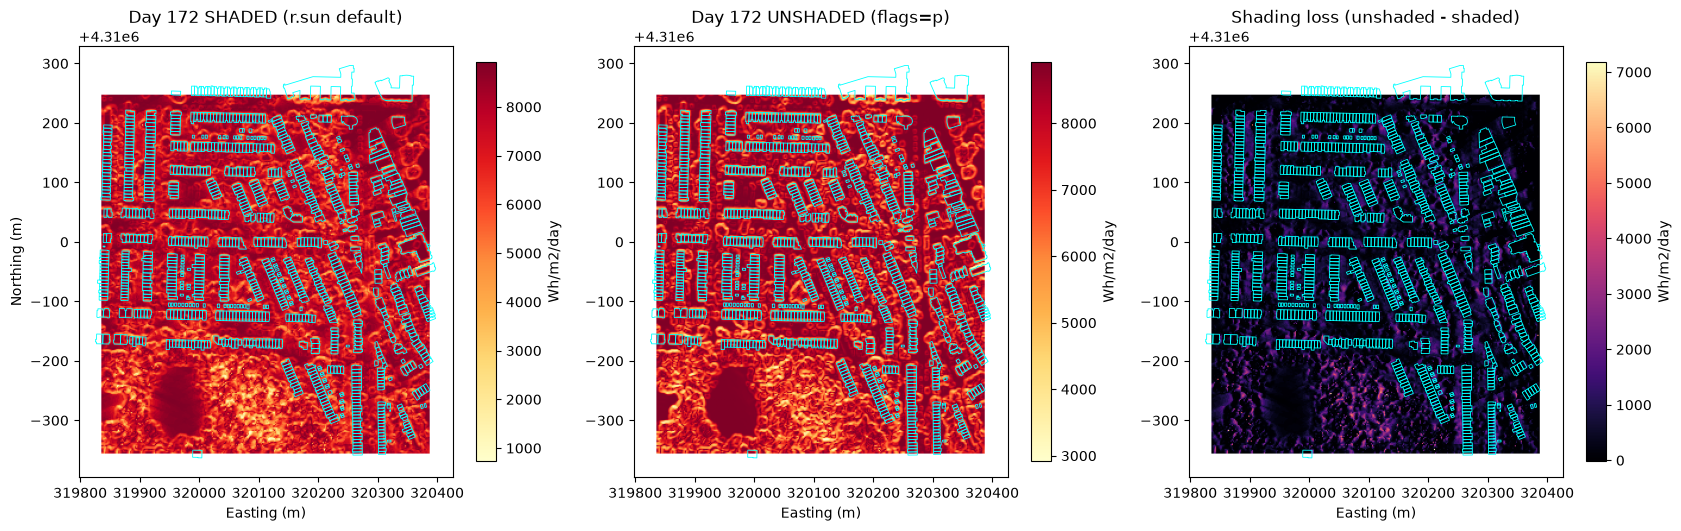

Mean shading loss, day 172: 5.4% of unshaded insolation
  loss INSIDE footprints (roofs)  :    113 Wh/m2/day
  loss OUTSIDE footprints (ground):    516 Wh/m2/day


In [4]:
shading_loss = unshaded_f - shaded_f  # Wh/m2/day lost to shadows, per cell

fig, axes = plt.subplots(1, 3, figsize=(17, 6))
for ax, data, title, cmap in [
    (axes[0], shaded_f, f"Day {DAY} SHADED (r.sun default)", "YlOrRd"),
    (axes[1], unshaded_f, f"Day {DAY} UNSHADED (flags=p)", "YlOrRd"),
    (axes[2], shading_loss, "Shading loss (unshaded - shaded)", "magma"),
]:
    im = ax.imshow(data, extent=extent, origin="upper", cmap=cmap)
    footprints_m.boundary.plot(ax=ax, edgecolor="cyan", lw=0.6)
    fig.colorbar(im, ax=ax, shrink=0.7, label="Wh/m2/day")
    ax.set_title(title); ax.set_xlabel("Easting (m)")
axes[0].set_ylabel("Northing (m)")
plt.tight_layout(); plt.show()

# Quantify: overall % loss, and loss inside footprints vs. open ground.
pct_loss_overall = 100.0 * np.nanmean(shading_loss) / np.nanmean(unshaded_f)
print(f"Mean shading loss, day {DAY}: {pct_loss_overall:.1f}% of unshaded insolation")

from rasterio.features import geometry_mask

inside = ~geometry_mask(
    [mapping(g) for g in footprints_m.geometry],
    out_shape=target_shape, transform=target_transform, invert=False,
)
loss_inside = np.nanmean(shading_loss[inside])
loss_outside = np.nanmean(shading_loss[~inside])
print(f"  loss INSIDE footprints (roofs)  : {loss_inside:6.0f} Wh/m2/day")
print(f"  loss OUTSIDE footprints (ground): {loss_outside:6.0f} Wh/m2/day")

## Approximating the annual, shaded insolation

The full production route (`radiation.py`) runs `r.sun` for all **365 days** and sums. That's
slow to demo interactively, so here we sample **one mid-month day per month** (a standard
solar-engineering shortcut) and weight each day's Wh/m2/day by its month's day-count before
summing -- a good approximation of the true annual total, at 12x the cost of one day instead of
365x.

We only run the **shaded** case here -- the unshaded case above already made its point (traps 1
and 4), and stage 6 only ever wants the shaded number.

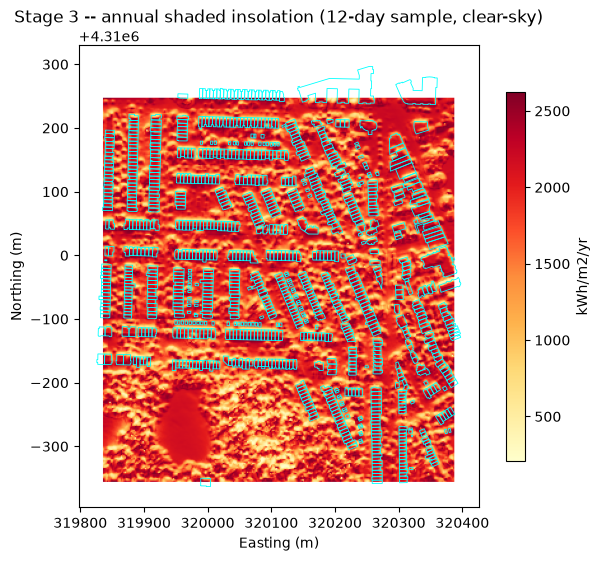

Annual shaded insolation (clear-sky, 12-day sample):
  mean 1827  min 207  max 2626  kWh/m2/yr


In [5]:
MID_MONTH_DAYS = [15, 45, 74, 105, 135, 162, 198, 228, 258, 288, 319, 349]
DAYS_IN_MONTH = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]

annual_wh = np.zeros(target_shape, dtype="float64")
annual_nodata_mask = np.zeros(target_shape, dtype=bool)

for doy, n_days in zip(MID_MONTH_DAYS, DAYS_IN_MONTH):
    day_arr, day_nodata = run_r_sun(gs, doy, shaded=True, workdir=workdir)
    day_f = masked(day_arr, day_nodata)
    annual_nodata_mask |= np.isnan(day_f)
    annual_wh += np.nan_to_num(day_f) * n_days

annual_kwh_m2 = annual_wh / 1000.0  # Wh -> kWh
annual_kwh_m2[annual_nodata_mask] = np.nan

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(annual_kwh_m2, extent=extent, origin="upper", cmap="YlOrRd")
footprints_m.boundary.plot(ax=ax, edgecolor="cyan", lw=0.6)
fig.colorbar(im, ax=ax, shrink=0.8, label="kWh/m2/yr")
ax.set_title("Stage 3 -- annual shaded insolation (12-day sample, clear-sky)")
ax.set_xlabel("Easting (m)"); ax.set_ylabel("Northing (m)"); plt.show()

print(f"Annual shaded insolation (clear-sky, 12-day sample):")
print(f"  mean {np.nanmean(annual_kwh_m2):.0f}  min {np.nanmin(annual_kwh_m2):.0f}  "
      f"max {np.nanmax(annual_kwh_m2):.0f}  kWh/m2/yr")

## Trap tie-ins

**Trap 4.** The `annual_kwh_m2` raster above (or, per roof plane, a **shading-loss factor** =
`shaded / unshaded` computed the same way as the day-172 panel) is exactly what stage 6
(`yield_pv.py`, PVWatts) must be fed. PVWatts's own irradiance assumption is an unshaded horizon;
if we hand it the raw NSRDB/NLR location value instead of this shaded surface, every hour of
shadow this notebook just computed gets silently thrown away and the yield is over-stated.

**Trap 3.** `r.sun`'s shadowing above only "sees" as far as the DSM extent we handed it (our
buffered tiny AOI). That's fine here -- Glover Park is low-rise and our buffer is generous
relative to building heights. Downtown, near much taller towers, the buffer alone isn't enough:
production should precompute horizon angles with `r.horizon` at a **large explicit search
distance** (its `maxdistance` parameter) so a caster well outside even a buffered AOI still
gets accounted for.

## What this established

- A throwaway **GRASS location/mapset** is enough to run `r.sun` end to end on a DSM fetched
  entirely in Python, with nothing written into the repo.
- **Shading is real and measurable**: on day 172, the shaded mean is a few percent below the
  unshaded mean overall (printed above) -- small because this slice is low-rise -- but the loss
  concentrates sharply on specific cells (see the shading-loss panel and the min values), which
  is exactly the inter-building effect a DTM-based run would have hidden entirely (trap 1).
- Sampling **12 mid-month days** gives a fast, honest approximation of annual clear-sky insolation
  (production loops all 365).
- Two shading traps (3, 4) are now concrete, not abstract.

**Next:** stage 4 -- fit roof planes (tilt + aspect) per building from the footprints + DSM, the
weakest link in the pipeline (risks §14.4).